**IMPORT DEPENDENCIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from joblib import dump
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**DATA PREPARATION**

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nishchalchandel/fertilizer-recommendation")

print("Path to dataset files:", path)
csv_path = os.path.join(path, 'fertilizer_recommendation_dataset.csv')

100%|██████████| 161k/161k [00:00<00:00, 70.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nishchalchandel/fertilizer-recommendation/versions/1


In [ ]:
df_raw = pd.read_csv(csv_path)
df_raw.columns = df_raw.columns.str.strip()
print(f"Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(df_raw.dtypes)

Dataset loaded: 3100 rows, 12 columns
Temperature    float64
Moisture       float64
Rainfall       float64
PH             float64
Nitrogen       float64
Phosphorous    float64
Potassium      float64
Carbon         float64
Soil            object
Crop            object
Fertilizer      object
Remark          object
dtype: object


**DATA EXPLORATION**

> Eksplorasi dilakukan pada data **mentah (sebelum encoding)** agar informasi kategorik tetap terbaca dan distribusi asli terlihat.

In [ ]:
print("--- DataFrame Information ---")
df_raw.info()

print("\n--- Descriptive Statistics for Numerical Columns ---")
print(df_raw.describe())

print("\n--- Missing Values Check ---")
print(df_raw.isnull().sum())

print("\n--- Unique Values and Counts for Categorical Columns ---")
for column in df_raw.select_dtypes(include='object').columns:
    print(f"\nColumn '{column}':")
    print(df_raw[column].value_counts())

print("\n--- First 5 Rows of DataFrame ---")
print(df_raw.head())

--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB

--- Descriptive Statistics for Numerical Columns ---
       Temperature     Moisture     Rainfall           PH     Nitrogen  \
count  3100.000000  3100.000000  3100.000000  3100.000000  3100.000000   
mean     27.271096 

**Analisis Karakteristik Data**

> Identifikasi nilai negatif yang tidak valid secara domain pada fitur numerik (curah hujan, fosfor, kalium, karbon tidak mungkin negatif di konteks pertanian).

In [ ]:
numerical_cols = ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']

print("=== CEK NILAI NEGATIF (ANOMALI DOMAIN) ===")
for col in numerical_cols:
    n_neg = (df_raw[col] < 0).sum()
    if n_neg > 0:
        print(f"  [!] {col}: {n_neg} nilai negatif (min={df_raw[col].min():.4f})")
    else:
        print(f"  [OK] {col}: tidak ada nilai negatif")

non_negative_cols = ['Rainfall', 'Phosphorous', 'Potassium', 'Carbon', 'Moisture', 'Nitrogen']
n_anomali = df_raw[non_negative_cols].lt(0).any(axis=1).sum()
print(f"\nTotal baris dengan anomali nilai negatif: {n_anomali} dari {len(df_raw)} baris")

=== CEK NILAI NEGATIF (ANOMALI DOMAIN) ===
  [OK] Temperature: tidak ada nilai negatif
  [OK] Moisture: tidak ada nilai negatif
  [!] Rainfall: 75 nilai negatif (min=-85.7096)
  [OK] PH: tidak ada nilai negatif
  [OK] Nitrogen: tidak ada nilai negatif
  [!] Phosphorous: 78 nilai negatif (min=-37.6497)
  [!] Potassium: 71 nilai negatif (min=-20.5091)
  [!] Carbon: 85 nilai negatif (min=-0.2806)

Total baris dengan anomali nilai negatif: 302 dari 3100 baris


**Data Cleaning**

> Hapus baris dengan nilai negatif pada fitur yang secara domain tidak mungkin negatif. Kolom `Remark` juga dipertahankan sementara untuk keperluan rekomendasi, baru dihapus setelah mapping dibuat.

In [ ]:
# Simpan mapping Remark SEBELUM drop (agar bisa dipakai di fungsi prediksi)
mapping_remark = (
    df_raw[['Fertilizer', 'Remark']]
    .drop_duplicates()
    .set_index('Fertilizer')['Remark']
    .to_dict()
)
print(f"Mapping remark berhasil disimpan untuk {len(mapping_remark)} jenis pupuk.")

# Filter baris dengan nilai negatif pada kolom non-negatif
non_negative_cols = ['Rainfall', 'Phosphorous', 'Potassium', 'Carbon', 'Moisture', 'Nitrogen']
mask_valid = df_raw[non_negative_cols].ge(0).all(axis=1)
df = df_raw[mask_valid].copy()
print(f"Data setelah cleaning: {len(df)} baris (dari {len(df_raw)} baris asli, {len(df_raw)-len(df)} dihapus)")

# Hapus kolom Remark
if 'Remark' in df.columns:
    df = df.drop('Remark', axis=1)

Mapping remark berhasil disimpan untuk 10 jenis pupuk.
Data setelah cleaning: 2798 baris (dari 3100 baris asli, 302 dihapus)


**DATA VISUALIZATION**

> Distribusi fitur numerik ditampilkan dari data yang sudah dibersihkan namun belum di-encode.

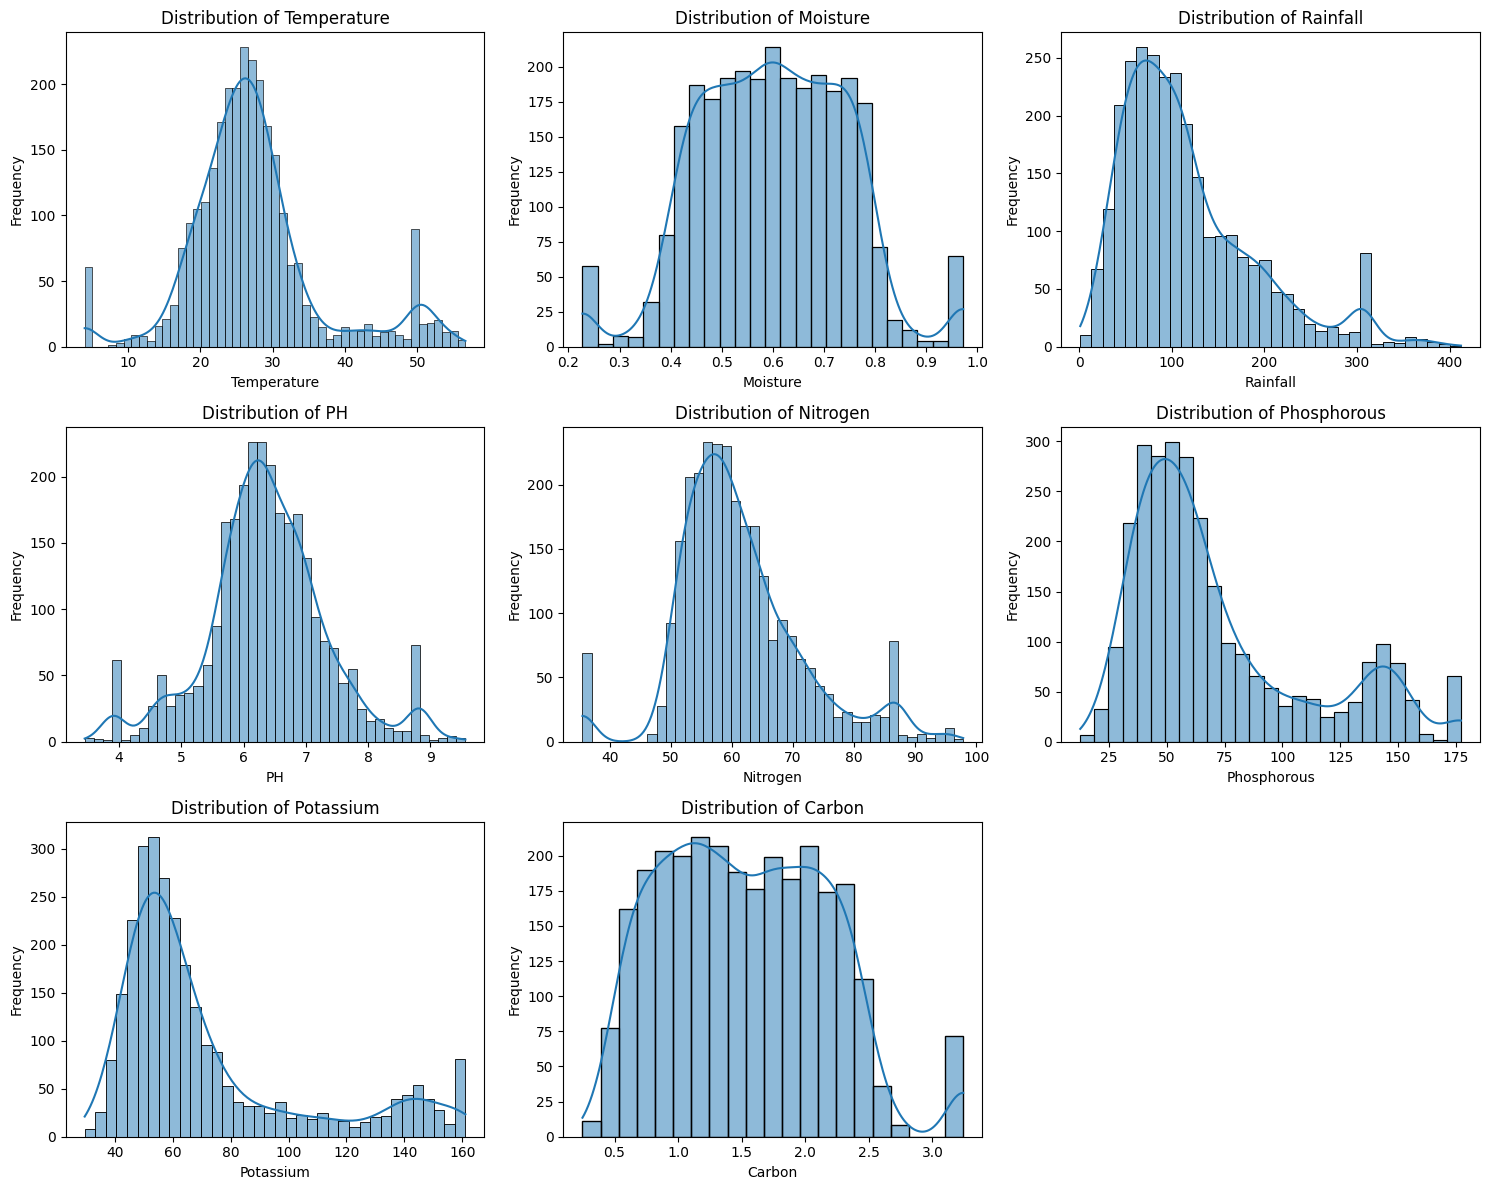

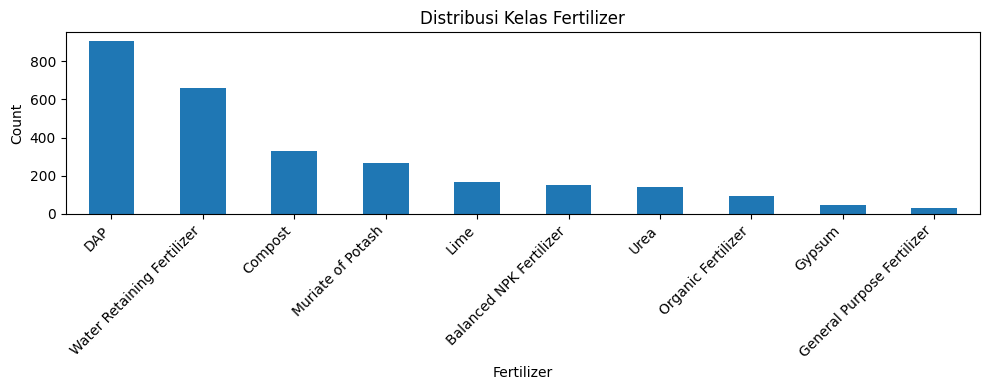

In [ ]:
numerical_cols = ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, feature in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Distribusi label target (sebelum encode)
plt.figure(figsize=(10, 4))
df['Fertilizer'].value_counts().plot(kind='bar')
plt.title('Distribusi Kelas Fertilizer')
plt.xlabel('Fertilizer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Encoding dan Data Split**

> Encoding dilakukan **setelah** EDA selesai. Tiga encoder terpisah digunakan (bukan satu `le` yang di-refit), agar setiap kolom bisa di-inverse_transform secara akurat.

Train: 2238 | Val: 280 | Test: 280

--- Correlation Matrix ---


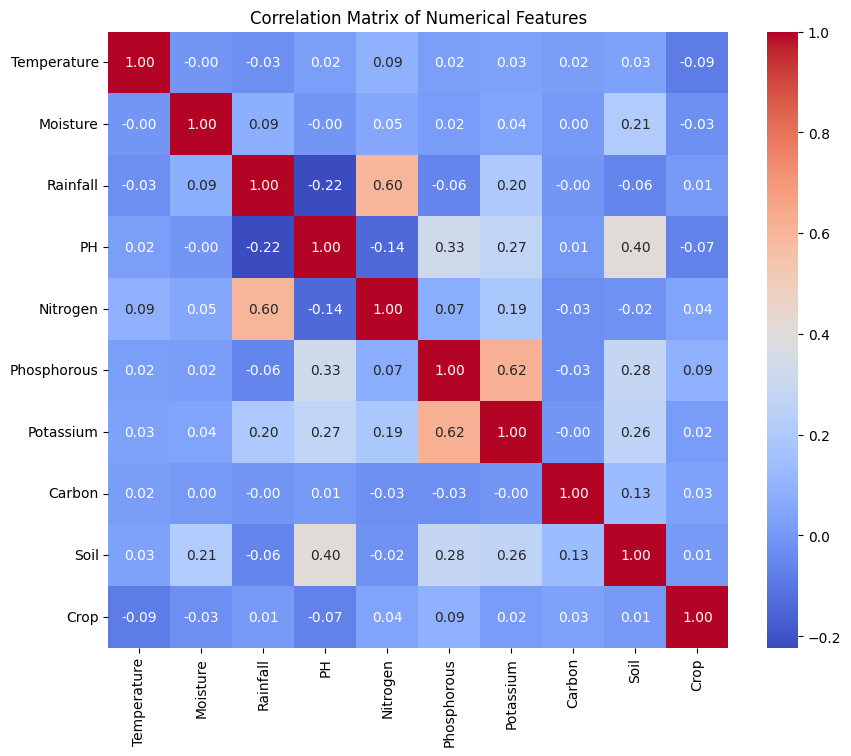

In [ ]:
# Fit encoder terpisah per kolom kategorik
soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
target_encoder = LabelEncoder()

df['Soil'] = soil_encoder.fit_transform(df['Soil'].astype(str))
df['Crop'] = crop_encoder.fit_transform(df['Crop'].astype(str))
df['Fertilizer'] = target_encoder.fit_transform(df['Fertilizer'].astype(str))

target_column = 'Fertilizer'
X = df.drop(target_column, axis=1)
y = df[target_column]

# Split: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

print("\n--- Correlation Matrix ---")
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Analisis Bias dan Variance**

In [ ]:
# --- ANALISIS BIAS & VARIANCE (BASELINE) ---
models_baseline = {
    'Decision Tree (Weak)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest (Bagging)': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost (Base)': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results_baseline = []

for name, model_base in models_baseline.items():
    model_base.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model_base.predict(X_train))
    test_acc = accuracy_score(y_test, model_base.predict(X_test))
    results_baseline.append({
        'Model': name,
        'Train_Acc': round(train_acc, 4),
        'Test_Acc': round(test_acc, 4),
        'Gap': round(train_acc - test_acc, 4)
    })

print("\n=== ANALISIS BIAS & VARIANCE (KLASIFIKASI) ===")
print(pd.DataFrame(results_baseline).to_string(index=False))


=== ANALISIS BIAS & VARIANCE (KLASIFIKASI) ===
                  Model  Train_Acc  Test_Acc     Gap
   Decision Tree (Weak)     0.8007    0.8036 -0.0029
Random Forest (Bagging)     1.0000    0.9857  0.0143
         XGBoost (Base)     1.0000    0.9893  0.0107


**TUNING DAN TRAINING**

In [ ]:
xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss')
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
print(f'\nParameter terbaik : {grid_search.best_params_}')
print(f'Akurasi terbaik (CV train) : {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits

Parameter terbaik : {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Akurasi terbaik (CV train) : 0.9911


**EVALUATION SCORE WITH VALIDATION DATA**

In [ ]:
y_pred_val = model.predict(X_val)

print(f"Akurasi Model Final (Validation): {accuracy_score(y_val, y_pred_val):.4f}")
print("\nLaporan Klasifikasi (Validation):\n")
print(classification_report(y_val, y_pred_val, target_names=target_encoder.classes_))

Akurasi Model Final (Validation): 0.9893

Laporan Klasifikasi (Validation):

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.94      1.00      0.97        15
                   Compost       1.00      0.94      0.97        33
                       DAP       0.99      1.00      0.99        91
General Purpose Fertilizer       1.00      1.00      1.00         3
                    Gypsum       0.83      1.00      0.91         5
                      Lime       1.00      1.00      1.00        17
         Muriate of Potash       1.00      0.96      0.98        26
        Organic Fertilizer       1.00      1.00      1.00        10
                      Urea       1.00      1.00      1.00        14
Water Retaining Fertilizer       1.00      1.00      1.00        66

                  accuracy                           0.99       280
                 macro avg       0.98      0.99      0.98       280
              weighted avg       0.99

**VALIDATION WITH K-FOLD**

> K-Fold dijalankan pada `X_train` untuk mengestimasi stabilitas model. Karena `GridSearchCV` sudah menggunakan `X_train` dengan `cv=3` untuk tuning, hasil K-Fold ini bersifat konfirmasi stabilitas, bukan estimasi generalisasi independen. Estimasi generalisasi yang benar-benar independen dilihat dari **Test Set** di langkah berikutnya.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=skf)

print("\n=== VALIDASI STRATIFIED K-FOLD (5-FOLD) ===")
print(f"Skor Akurasi per Fold: {cv_scores}")
print(f"Rata-rata Akurasi CV : {cv_scores.mean():.4f}")
print(f"Standar Deviasi CV   : {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\nInterpretasi: Standar deviasi rendah menunjukkan model yang sangat stabil.")
else:
    print("\nInterpretasi: Ada sedikit fluktuasi, tapi model tetap cukup baik.")


=== VALIDASI STRATIFIED K-FOLD (5-FOLD) ===
Skor Akurasi per Fold: [0.984375   0.99330357 0.99553571 0.99776286 0.99552573]
Rata-rata Akurasi CV : 0.9933
Standar Deviasi CV   : 0.0047

Interpretasi: Standar deviasi rendah menunjukkan model yang sangat stabil.


**EVALUATION WITH TESTING DATA**

=== Model Evaluation on Test Data ===
Test Accuracy: 0.9929

Classification Report for Test Set:

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        16
                   Compost       1.00      1.00      1.00        33
                       DAP       0.98      1.00      0.99        90
General Purpose Fertilizer       1.00      1.00      1.00         3
                    Gypsum       1.00      1.00      1.00         5
                      Lime       1.00      1.00      1.00        17
         Muriate of Potash       1.00      1.00      1.00        27
        Organic Fertilizer       1.00      1.00      1.00         9
                      Urea       1.00      0.86      0.92        14
Water Retaining Fertilizer       1.00      1.00      1.00        66

                  accuracy                           0.99       280
                 macro avg       1.00      0.99      0.99       280
              we

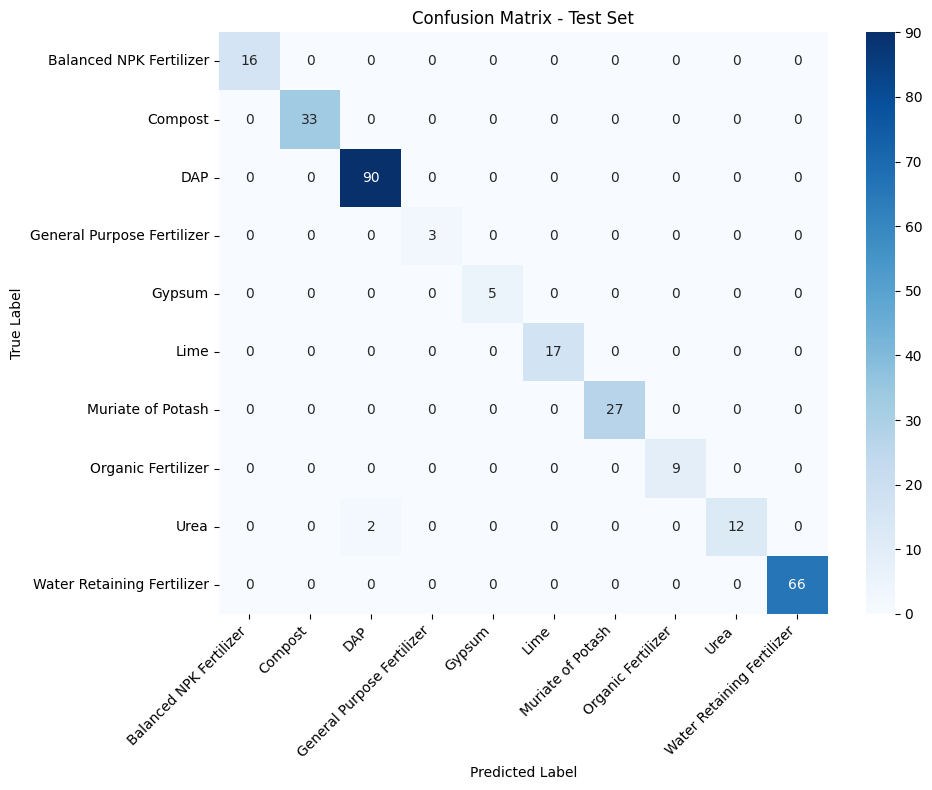

In [ ]:
y_pred_test = model.predict(X_test)

print("=== Model Evaluation on Test Data ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nClassification Report for Test Set:\n")
print(classification_report(y_test, y_pred_test, target_names=target_encoder.classes_))

# Analisis kelas dengan performa rendah
report_dict = classification_report(y_test, y_pred_test,
                                    target_names=target_encoder.classes_,
                                    output_dict=True)
low_recall = [(k, v['recall']) for k, v in report_dict.items()
              if k not in ['accuracy', 'macro avg', 'weighted avg'] and v['recall'] < 0.80]
if low_recall:
    print("\n[!] Kelas dengan recall < 0.80 (perlu perhatian):")
    for cls, rec in low_recall:
        print(f"   - {cls}: recall = {rec:.2f}")
else:
    print("\n[OK] Semua kelas memiliki recall >= 0.80")

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**MODEL INTERPRETATION**

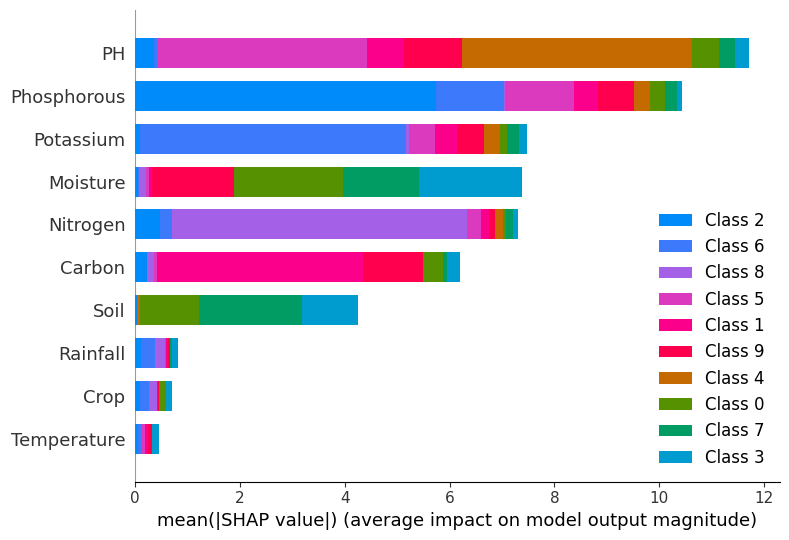

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

**FUNGSI REKOMENDASI PUPUK**

> Menggunakan encoder yang sudah di-fit sebelumnya. Tidak perlu reload CSV.

In [ ]:
def rekomendasi_pupuk(data_input):
    """
    Memprediksi rekomendasi pupuk berdasarkan kondisi lahan.

    Parameters:
        data_input (dict): Data kondisi lahan dengan kunci:
            Temperature, Moisture, Rainfall, PH, Nitrogen,
            Phosphorous, Potassium, Carbon, Soil (str), Crop (str)

    Returns:
        tuple: (nama_pupuk, penjelasan)
    """
    input_df = pd.DataFrame([data_input])
    input_df['Soil'] = soil_encoder.transform(input_df['Soil'])
    input_df['Crop'] = crop_encoder.transform(input_df['Crop'])

    pred = model.predict(input_df)
    fertilizer = target_encoder.inverse_transform(pred)[0]
    remark = mapping_remark.get(fertilizer, "Tidak ada keterangan.")

    print("\n=== HASIL REKOMENDASI ===")
    print(f"Pupuk      : {fertilizer}")
    print(f"Penjelasan : {remark}")
    return fertilizer, remark

# Contoh pemakaian
rekomendasi_pupuk({
    'Temperature': 25,
    'Moisture': 0.7,
    'Rainfall': 200,
    'PH': 6.5,
    'Nitrogen': 70,
    'Phosphorous': 60,
    'Potassium': 80,
    'Carbon': 1.2,
    'Soil': 'Loamy Soil',
    'Crop': 'rice'
})


=== HASIL REKOMENDASI ===
Pupuk      : Water Retaining Fertilizer
Penjelasan : Improves water retention in dry soils. Prefer this for soils with low moisture to prevent water stress in plants.


('Water Retaining Fertilizer',
 'Improves water retention in dry soils. Prefer this for soils with low moisture to prevent water stress in plants.')